In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
POINTS = set() # Tuple of (bins, pulls) points

LOWBINS = 100
HIGHBINS = 1000
LOWPULLS = 40
HIGHPULLS = 640

i = LOWBINS
j = 10
while j <= 1000:
    POINTS.add((i, j))
    j += 30
i = HIGHBINS
j = 10
while j <= 1000:
    POINTS.add((i, j))
    j += 30

j = LOWPULLS
i = 50
while i <= 1500:
    POINTS.add((i, j))
    i += 50
j = HIGHPULLS
i = 50
while i <= 1500:
    POINTS.add((i, j))
    i += 50

POINTS = np.array(list(POINTS)) # Convert set to list
print(POINTS)

[[1000  190]
 [1000  910]
 [ 100   10]
 [ 100  730]
 [1350   40]
 [ 100  220]
 [ 100  940]
 [1000  220]
 [1000  940]
 [1300  640]
 [1500  640]
 [ 100  430]
 [1000  430]
 [ 850   40]
 [1050   40]
 [ 800  640]
 [1000  640]
 [ 100  460]
 [ 350   40]
 [1250   40]
 [ 550   40]
 [ 100  670]
 [1450   40]
 [1000  670]
 [ 300  640]
 [1200  640]
 [ 500  640]
 [1400  640]
 [ 700  640]
 [ 100  160]
 [ 100  880]
 [1000  160]
 [1000  880]
 [ 750   40]
 [  50   40]
 [ 950   40]
 [1150   40]
 [1000  370]
 [ 900  640]
 [ 200  640]
 [ 100  190]
 [ 100  910]
 [1100  640]
 [ 250   40]
 [ 450   40]
 [ 100  400]
 [1000  400]
 [ 650   40]
 [ 400  640]
 [ 600  640]
 [ 100  610]
 [1000  610]
 [ 150   40]
 [1000  100]
 [1000  820]
 [ 100  640]
 [ 100  130]
 [ 100  850]
 [1000  130]
 [1000  850]
 [ 100  340]
 [1000  340]
 [1250  640]
 [1000  550]
 [ 100  370]
 [ 800   40]
 [ 100  580]
 [ 750  640]
 [1000  580]
 [ 100   70]
 [ 100  790]
 [1000   70]
 [1000  790]
 [ 300   40]
 [1200   40]
 [ 500   40]
 [1400   40]

In [3]:
# --- Define options for 1d plots --- #
PARAM_PULL = True # If False, x-axis is number of pulls. If True, x-axis is number of bins.
CONST = HIGHPULLS

if PARAM_PULL:
    POINTS = np.array(sorted(POINTS, key=lambda x: (x[0], x[1]))) # Sort by bins
else:
    POINTS = np.array(sorted(POINTS, key=lambda x: (x[1], x[0]))) # Sort by pulls

print(POINTS)

[[  50   40]
 [  50  640]
 [ 100   10]
 [ 100   40]
 [ 100   70]
 [ 100  100]
 [ 100  130]
 [ 100  160]
 [ 100  190]
 [ 100  220]
 [ 100  250]
 [ 100  280]
 [ 100  310]
 [ 100  340]
 [ 100  370]
 [ 100  400]
 [ 100  430]
 [ 100  460]
 [ 100  490]
 [ 100  520]
 [ 100  550]
 [ 100  580]
 [ 100  610]
 [ 100  640]
 [ 100  670]
 [ 100  700]
 [ 100  730]
 [ 100  760]
 [ 100  790]
 [ 100  820]
 [ 100  850]
 [ 100  880]
 [ 100  910]
 [ 100  940]
 [ 100  970]
 [ 100 1000]
 [ 150   40]
 [ 150  640]
 [ 200   40]
 [ 200  640]
 [ 250   40]
 [ 250  640]
 [ 300   40]
 [ 300  640]
 [ 350   40]
 [ 350  640]
 [ 400   40]
 [ 400  640]
 [ 450   40]
 [ 450  640]
 [ 500   40]
 [ 500  640]
 [ 550   40]
 [ 550  640]
 [ 600   40]
 [ 600  640]
 [ 650   40]
 [ 650  640]
 [ 700   40]
 [ 700  640]
 [ 750   40]
 [ 750  640]
 [ 800   40]
 [ 800  640]
 [ 850   40]
 [ 850  640]
 [ 900   40]
 [ 900  640]
 [ 950   40]
 [ 950  640]
 [1000   10]
 [1000   40]
 [1000   70]
 [1000  100]
 [1000  130]
 [1000  160]
 [1000  190]

In [4]:
# dict -> (nbinns, npulls) : [process_time, fill_spectra_all_time, fill_spectra_phys_time, fill_spectra_nuis_time, chi2_no_grad_time, chi2_with_grad_time]

valid_process_times_points = np.array([(0,0)])
valid_fill_spectra_all_times_points = np.array([(0,0)])
valid_fill_spectra_phys_times_points = np.array([(0,0)])
valid_fill_spectra_nuis_times_points = np.array([(0,0)])
valid_chi2_no_grad_times_points = np.array([(0,0)])
valid_chi2_with_grad_times_points = np.array([(0,0)])

times_dict = {}
for bins, pulls in POINTS:
    process_time = -1
    fill_spectra_all_time = -1
    fill_spectra_phys_time = -1
    fill_spectra_nuis_time = -1
    chi2_no_grad_time = -1
    chi2_with_grad_time = -1

    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    fill_spectra_all_time = time
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    fill_spectra_phys_time = time
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    fill_spectra_nuis_time = time
            elif 'metric_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    chi2_no_grad_time = time
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    chi2_with_grad_time = time
    f.close()

    with open(f'./time_logs/user_{bins}bins_{pulls}pulls_time.txt', 'r') as f2:
        line = f2.readline()
        try:
            time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
            process_time = time
        except:
            process_time = -1
    f2.close()

    times_dict[(bins, pulls)] = [process_time, fill_spectra_all_time, fill_spectra_phys_time, fill_spectra_nuis_time, chi2_no_grad_time, chi2_with_grad_time]

    if process_time != -1:
        valid_process_times_points = np.append(valid_process_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_all_time != -1:
        valid_fill_spectra_all_times_points = np.append(valid_fill_spectra_all_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_phys_time != -1:
        valid_fill_spectra_phys_times_points = np.append(valid_fill_spectra_phys_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_nuis_time != -1:
        valid_fill_spectra_nuis_times_points = np.append(valid_fill_spectra_nuis_times_points, [(bins, pulls)], axis=0)
    if chi2_no_grad_time != -1:
        valid_chi2_no_grad_times_points = np.append(valid_chi2_no_grad_times_points, [(bins, pulls)], axis=0)
    if chi2_with_grad_time != -1:
        valid_chi2_with_grad_times_points = np.append(valid_chi2_with_grad_times_points, [(bins, pulls)], axis=0)
    
valid_process_times_points = valid_process_times_points[1:]
valid_fill_spectra_all_times_points = valid_fill_spectra_all_times_points[1:]
valid_fill_spectra_phys_times_points = valid_fill_spectra_phys_times_points[1:]
valid_fill_spectra_nuis_times_points = valid_fill_spectra_nuis_times_points[1:]
valid_chi2_no_grad_times_points = valid_chi2_no_grad_times_points[1:]
valid_chi2_with_grad_times_points = valid_chi2_with_grad_times_points[1:]

In [5]:
process_times = np.array([])
fill_spectra_all_times = np.array([])
fill_spectra_phys_times = np.array([])
fill_spectra_nuis_times = np.array([])
chi2_no_grad_times = np.array([])
chi2_with_grad_times = np.array([])

for bins, pulls in valid_process_times_points:
    process_times = np.append(process_times, times_dict[(bins, pulls)][0])

for bins, pulls in valid_fill_spectra_all_times_points:
    fill_spectra_all_times = np.append(fill_spectra_all_times, times_dict[(bins, pulls)][1])

for bins, pulls in valid_fill_spectra_phys_times_points:
    fill_spectra_phys_times = np.append(fill_spectra_phys_times, times_dict[(bins, pulls)][2])

for bins, pulls in valid_fill_spectra_nuis_times_points:
    fill_spectra_nuis_times = np.append(fill_spectra_nuis_times, times_dict[(bins, pulls)][3])

for bins, pulls in valid_chi2_no_grad_times_points:
    chi2_no_grad_times = np.append(chi2_no_grad_times, times_dict[(bins, pulls)][4])

for bins, pulls in valid_chi2_with_grad_times_points:
    chi2_with_grad_times = np.append(chi2_with_grad_times, times_dict[(bins, pulls)][5])

In [6]:
process_x0 = np.array([])
process_y0 = np.array([])
fs_all_x0 = np.array([])
fs_all_y0 = np.array([])
fs_phys_x0 = np.array([])
fs_phys_y0 = np.array([])
fs_nuis_x0 = np.array([])
fs_nuis_y0 = np.array([])
chi2_no_x0 = np.array([])
chi2_no_y0 = np.array([])
chi2_with_x0 = np.array([])
chi2_with_y0 = np.array([])

for bins, pulls in valid_process_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        process_x0 = np.append(process_x0, add)
        process_y0 = np.append(process_y0, times_dict[(bins, pulls)][0])

for bins, pulls in valid_fill_spectra_all_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        fs_all_x0 = np.append(fs_all_x0, add)
        fs_all_y0 = np.append(fs_all_y0, times_dict[(bins, pulls)][1])

for bins, pulls in valid_fill_spectra_phys_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        fs_phys_x0 = np.append(fs_phys_x0, add)
        fs_phys_y0 = np.append(fs_phys_y0, times_dict[(bins, pulls)][2])

for bins, pulls in valid_fill_spectra_nuis_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        fs_nuis_x0 = np.append(fs_nuis_x0, add)
        fs_nuis_y0 = np.append(fs_nuis_y0, times_dict[(bins, pulls)][3])

for bins, pulls in valid_chi2_no_grad_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        chi2_no_x0 = np.append(chi2_no_x0, add)
        chi2_no_y0 = np.append(chi2_no_y0, times_dict[(bins, pulls)][4])

for bins, pulls in valid_chi2_with_grad_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        chi2_with_x0 = np.append(chi2_with_x0, add)
        chi2_with_y0 = np.append(chi2_with_y0, times_dict[(bins, pulls)][5])

In [7]:
def exponential_func(x, a, b):
    return a * np.exp(b * x)

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

def linear_func(x, a, b):
    return a * x + b

params_exp, covar_exp = curve_fit(exponential_func, fs_all_x0, fs_all_y0, p0=(100, 0.006))
exp_residuals = fs_all_y0 - exponential_func(fs_all_x0, *params_exp)
exp_ss_res = np.sum(exp_residuals**2)
exp_ss_tot = np.sum((fs_all_y0 - np.mean(fs_all_y0))**2)
exp_r_squared = 1 - (exp_ss_res / exp_ss_tot)

params_quad, covar_quad = curve_fit(quadratic_func, fs_all_x0, fs_all_y0)
quad_residuals = fs_all_y0 - quadratic_func(fs_all_x0, *params_quad)
quad_ss_res = np.sum(quad_residuals**2)
quad_ss_tot = np.sum((fs_all_y0 - np.mean(fs_all_y0))**2)
quad_r_squared = 1 - (quad_ss_res / quad_ss_tot)

params_lin, covar_lin = curve_fit(linear_func, fs_all_x0, fs_all_y0)
lin_residuals = fs_all_y0 - linear_func(fs_all_x0, *params_lin)
lin_ss_res = np.sum(lin_residuals**2)
lin_ss_tot = np.sum((fs_all_y0 - np.mean(fs_all_y0))**2)
lin_r_squared = 1 - (lin_ss_res / lin_ss_tot)

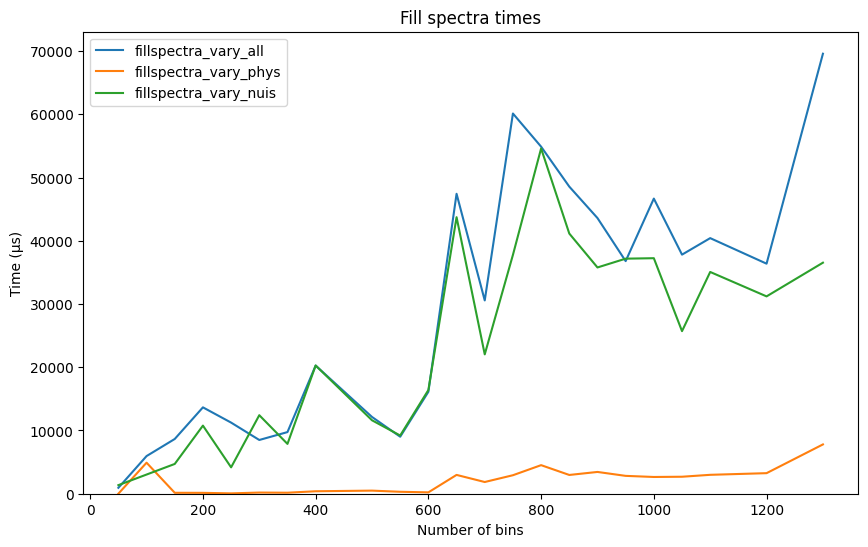

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(fs_all_x0, fs_all_y0, label='fillspectra_vary_all')
plt.plot(fs_phys_x0, fs_phys_y0, label='fillspectra_vary_phys')
plt.plot(fs_nuis_x0, fs_nuis_y0, label='fillspectra_vary_nuis')
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
else:
    plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

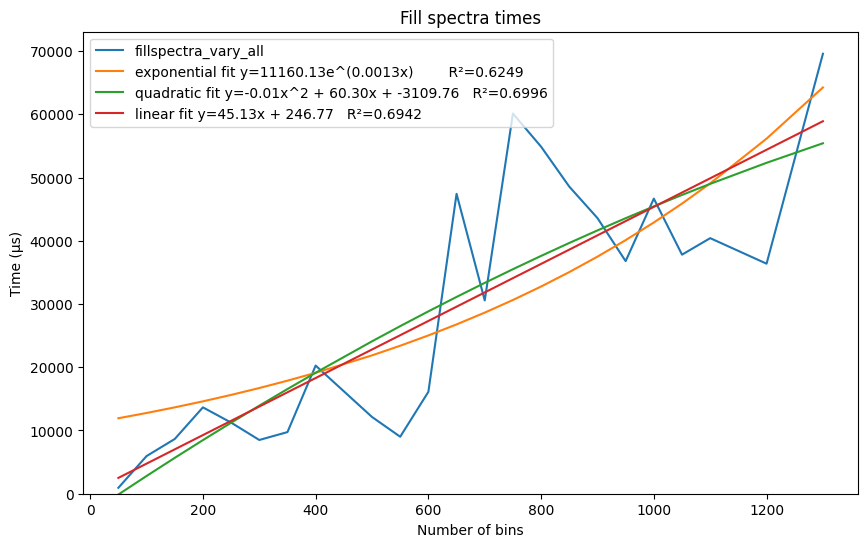

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(fs_all_x0, fs_all_y0, label='fillspectra_vary_all')
plt.plot(fs_all_x0, exponential_func(fs_all_x0, *params_exp), label='exponential fit y=%.2fe^(%.4fx)        R²=%.4f' % (*tuple(params_exp), exp_r_squared))
plt.plot(fs_all_x0, quadratic_func(fs_all_x0, *params_quad), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(params_quad), quad_r_squared))
plt.plot(fs_all_x0, linear_func(fs_all_x0, *params_lin), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(params_lin), lin_r_squared))
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
else:
    plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

In [10]:
chi_quad_params, chi_covar_quad = curve_fit(quadratic_func, chi2_with_x0, chi2_with_y0)
chi_quad_residuals = chi2_with_y0 - quadratic_func(chi2_with_x0, *chi_quad_params)
chi_quad_ss_res = np.sum(chi_quad_residuals**2)
chi_quad_ss_tot = np.sum((chi2_with_y0 - np.mean(chi2_with_y0))**2)
chi_quad_r_squared = 1 - (chi_quad_ss_res / chi_quad_ss_tot)

chi_lin_params, chi_covar_lin = curve_fit(linear_func, chi2_with_x0, chi2_with_y0)
chi_lin_residuals = chi2_with_y0 - linear_func(chi2_with_x0, *chi_lin_params)
chi_lin_ss_res = np.sum(chi_lin_residuals**2)
chi_lin_ss_tot = np.sum((chi2_with_y0 - np.mean(chi2_with_y0))**2)
chi_lin_r_squared = 1 - (chi_lin_ss_res / chi_lin_ss_tot)

chi_exp_params, chi_covar_exp = curve_fit(exponential_func, chi2_with_x0, chi2_with_y0, p0=(100, 0.006))
chi_exp_residuals = chi2_with_y0 - exponential_func(chi2_with_x0, *chi_exp_params)
chi_exp_ss_res = np.sum(chi_exp_residuals**2)
chi_exp_ss_tot = np.sum((chi2_with_y0 - np.mean(chi2_with_y0))**2)
chi_exp_r_squared = 1 - (chi_exp_ss_res / chi_exp_ss_tot)

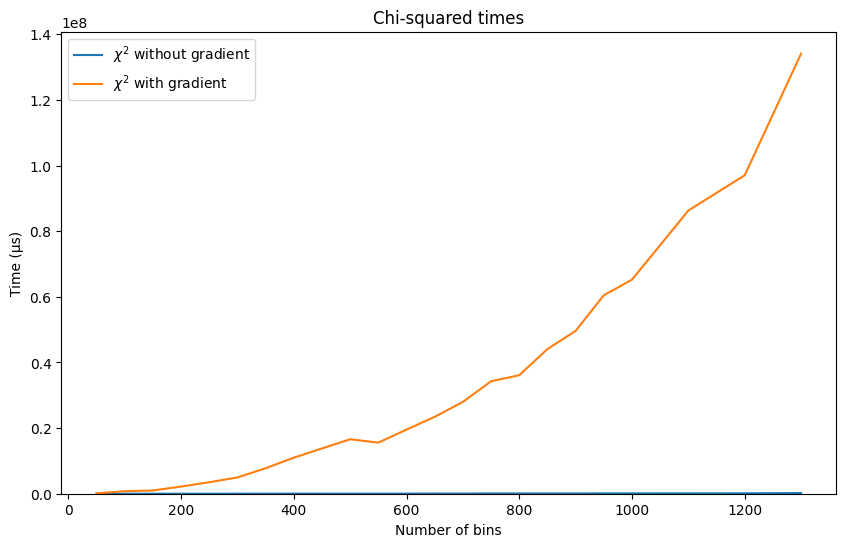

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(chi2_no_x0, chi2_no_y0, label='$\\chi^2$ without gradient')
plt.plot(chi2_with_x0, chi2_with_y0, label='$\\chi^2$ with gradient')
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
else:
    plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

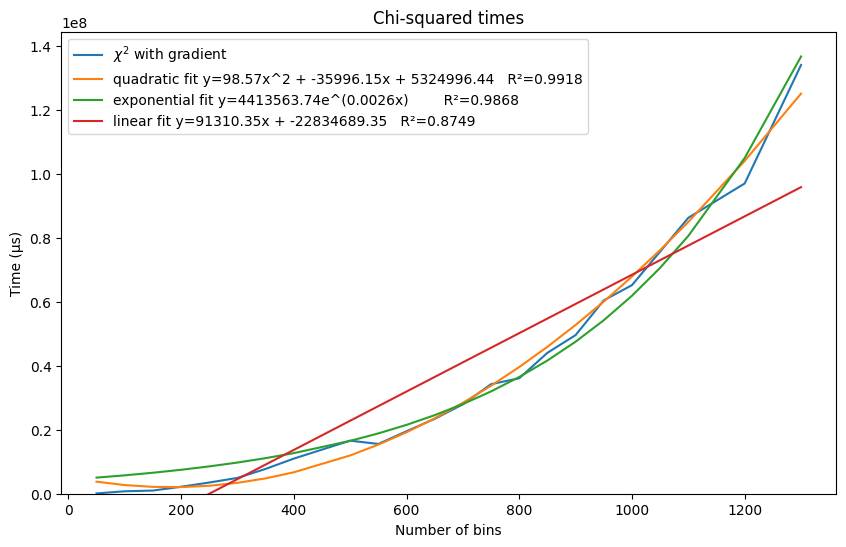

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(chi2_with_x0, chi2_with_y0, label='$\\chi^2$ with gradient')
plt.plot(chi2_with_x0, quadratic_func(chi2_with_x0, *chi_quad_params), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(chi_quad_params), chi_quad_r_squared))
plt.plot(chi2_with_x0, exponential_func(chi2_with_x0, *chi_exp_params), label='exponential fit y=%.2fe^(%.4fx)        R²=%.4f' % (*tuple(chi_exp_params), chi_exp_r_squared))
plt.plot(chi2_with_x0, linear_func(chi2_with_x0, *chi_lin_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(chi_lin_params), chi_lin_r_squared))
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
else:
    plt.xlabel('Number of pulls')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

In [13]:
def sqrt_func(x, a, b):
    return a * np.sqrt(x) + b

def log_func(x, a, b):
    return a * np.log(x) + b

sqrt_params, sqrt_covar = curve_fit(sqrt_func, process_x0, process_y0)
sqrt_residuals = process_y0 - sqrt_func(process_x0, *sqrt_params)
sqrt_ss_res = np.sum(sqrt_residuals**2)
sqrt_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)
sqrt_r_squared = 1 - (sqrt_ss_res / sqrt_ss_tot)

log_params, log_covar = curve_fit(log_func, process_x0, process_y0)
log_residuals = process_y0 - log_func(process_x0, *log_params)
log_ss_res = np.sum(log_residuals**2)
log_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)
log_r_squared = 1 - (log_ss_res / log_ss_tot)

lin_params, lin_covar = curve_fit(linear_func, process_x0, process_y0)
lin_residuals = process_y0 - linear_func(process_x0, *lin_params)
lin_ss_res = np.sum(lin_residuals**2)
lin_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)
lin_r_squared = 1 - (lin_ss_res / lin_ss_tot)

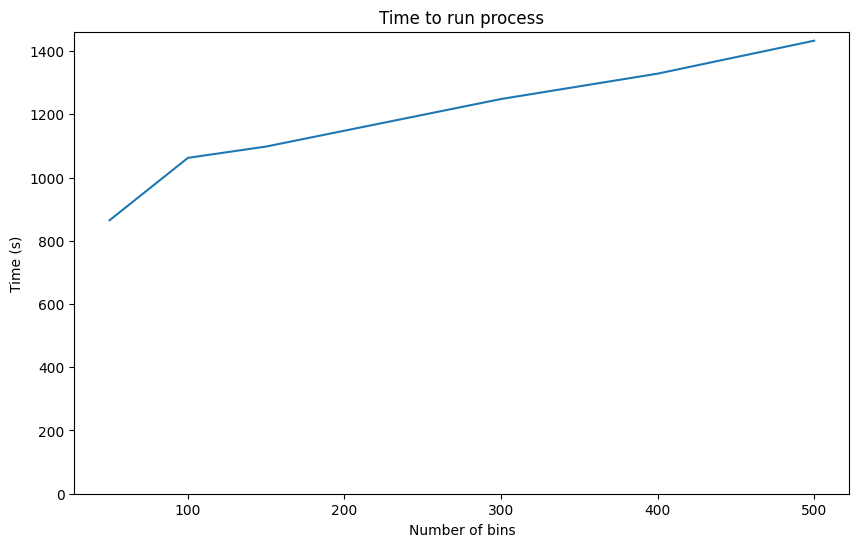

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(process_x0, process_y0)
if PARAM_PULL:
    plt.xlabel('Number of bins')
else:
    plt.xlabel('Number of pulls')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()

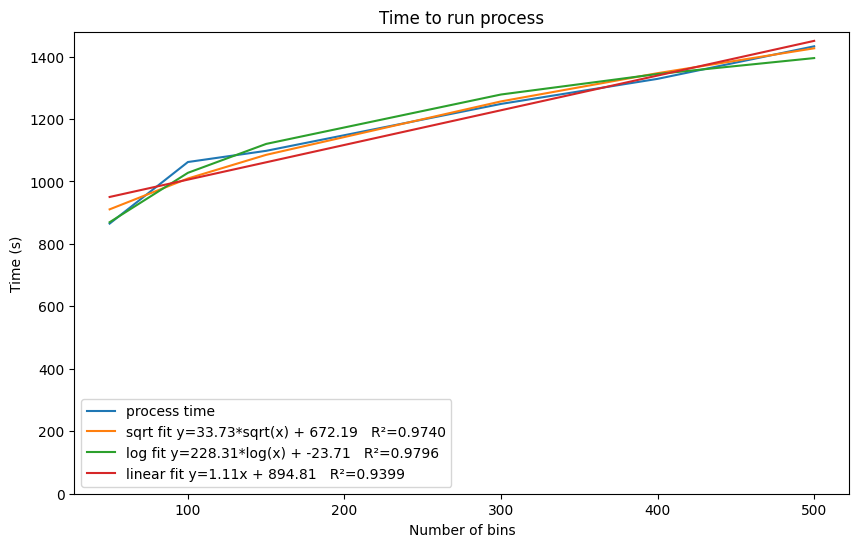

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(process_x0, process_y0, label='process time')
plt.plot(process_x0, sqrt_func(process_x0, *sqrt_params), label='sqrt fit y=%.2f*sqrt(x) + %.2f   R²=%.4f' % (*tuple(sqrt_params), sqrt_r_squared))
plt.plot(process_x0, log_func(process_x0, *log_params), label='log fit y=%.2f*log(x) + %.2f   R²=%.4f' % (*tuple(log_params), log_r_squared))
plt.plot(process_x0, linear_func(process_x0, *lin_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(lin_params), lin_r_squared))
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
else:
    plt.xlabel('Number of pulls')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()

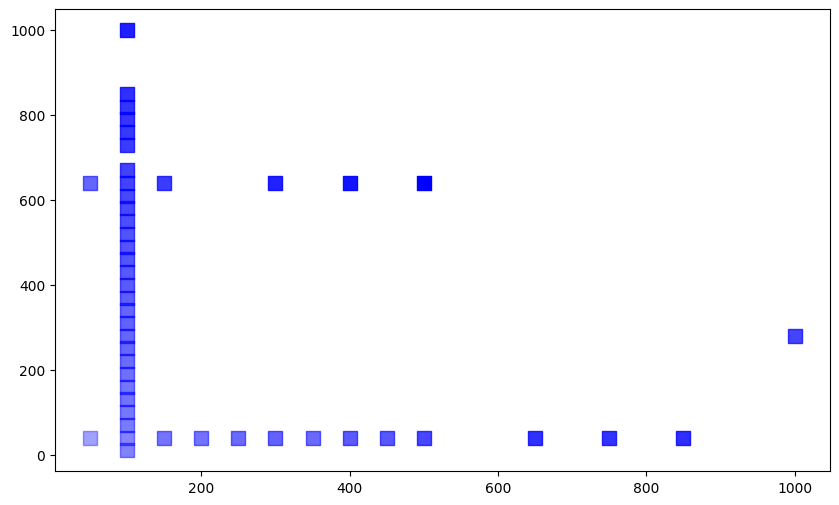

In [16]:
plt.figure(figsize=(10, 6))
for bins, pulls in valid_process_times_points:
    plt.scatter(bins, pulls, color='b', alpha=times_dict[(bins, pulls)][0]/max(process_times), marker='s', s=100)
plt.show()

In [17]:
# 20 norms vs 20 splines and 10 norms vs 10 splines to see if they take the same time to run with the same number of bins
# Also check if repeating the same name for splines could work

tags = np.array(['pulltest_10norm', 'pulltest_20norm', 'pulltest_10repeat_spline', 'pulltest_20repeat_spline', 'pulltest_10spline', 'pulltest_20spline'])

pulltest_process_times = np.array([])
pulltest_fill_spectra_times = np.array([])
pulltest_chi2_with_grad_times = np.array([])

for tag in tags:
    with open(f'./scaling_outputs/scale_{tag}.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_fill_spectra_times = np.append(pulltest_fill_spectra_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_chi2_with_grad_times = np.append(pulltest_chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{tag}_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        pulltest_process_times = np.append(pulltest_process_times, time)
    f2.close()

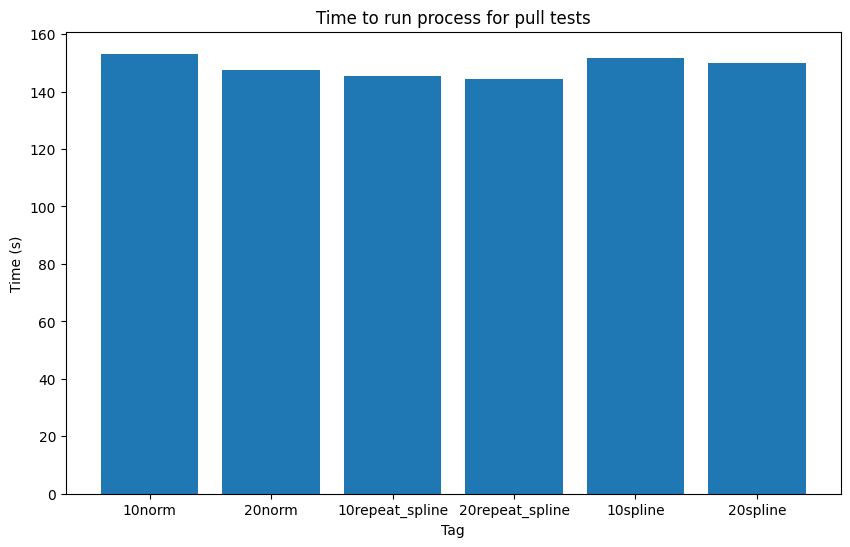

In [18]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_process_times)
plt.xlabel('Tag')
plt.ylabel('Time (s)')
plt.title('Time to run process for pull tests')
plt.ylim(0,)
plt.show()

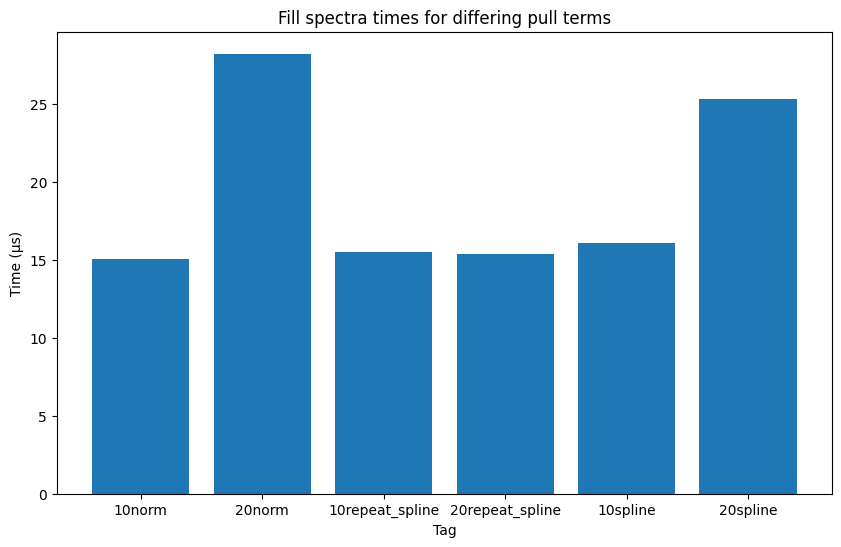

In [19]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_fill_spectra_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times for differing pull terms')
plt.ylim(0,)
plt.show()

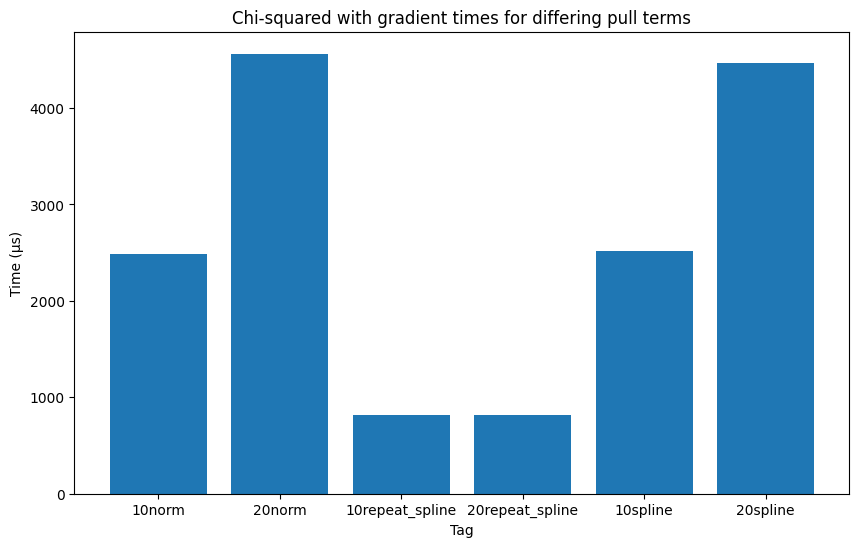

In [20]:
plt.figure(figsize=(10, 6))
plt.bar([t[9:] for t in tags], pulltest_chi2_with_grad_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Chi-squared with gradient times for differing pull terms')
plt.ylim(0,)
plt.show()

Issues: 
```
terminate called after throwing an instance of 'boost::archive::archive_exception'
  what():  input stream error
run.sh: line 19: 385130 Aborted                 (core dumped)
```
`grep: write error: No space left on device`
```
1 main || Default-CV collapsed bin 1230 has 0 expected events (<=0). Empty-bin would make CNP/stat covariance singular.
```